
# TCC II — Protótipo enxuto em um único notebook

Este notebook implementa uma **versão reduzida do fluxo metodológico do TCC**, usando apenas a base de **janeiro de 2025** como teste inicial.

Fluxo:

1. Ler o arquivo `NotaFiscalItem`.
2. Selecionar a descrição do produto.
3. Amostrar os dados para um experimento rápido.
4. Normalizar as descrições.
5. Consolidar duplicatas exatas e manter sua frequência.
6. Gerar representações **TF-IDF** com n-grams de palavras e caracteres.
7. Testar alguns valores de **k** no **K-Means**.
8. Comparar métricas internas.
9. Inspecionar exemplos representativos dos clusters.
10. Gerar prompts para apoio de uma LLM na nomeação.
11. Criar uma taxonomia manual simples.
12. Categorizar novas descrições.

> Este notebook é um **smoke test da metodologia**, não o experimento final do TCC.  
> No trabalho final, aumente a amostra, amplie a faixa de `k`, registre todos os experimentos e faça a avaliação qualitativa completa.


In [9]:
from pathlib import Path
import csv
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)

warnings.filterwarnings("ignore")

In [ ]:
RANDOM_STATE = 42

CSV_PATH = r"C:\Users\samue\Scripts\Nofis-Classifier\data\raw\202501_NFe\202501_NFe_NotaFiscalItem.csv"

SAMPLE_SIZE = 20_000

K_VALUES = [10, 15, 20, 25, 30]

MAX_FEATURES = 10_000

print("Arquivo configurado: ", CSV_PATH)


Arquivo configurado:  C:\Users\samue\Scripts\Nofis-Classifier\data\raw\202501_NFe\202501_NFe_NotaFiscalItem.csv


## 1. Leitura da base


O TCC define cada item fiscal como unidade de análise e usa principalmente o campo de **descrição do produto/serviço**.  
O código abaixo tenta identificar automaticamente essa coluna, mas você pode informar o nome manualmente se necessário.


In [6]:
description_col = "DESCRIÇÃO DO PRODUTO/SERVIÇO"

In [13]:

df = pd.read_csv(
    CSV_PATH,
    sep=";",
    encoding="cp1252",
    decimal=",",
    usecols=[description_col],
    dtype={description_col: "string"},
)

df = df.rename(columns={description_col: "descricao_original"})

print(f"Registros carregados: {len(df):}")
display(df.head(10))


Registros carregados: 369683


,descricao_original
0,FREEZER VERTICAL 1 PORTA 220V
1,DS DIESEL S10 COMUM
2,GC GASOLINA COMUM
3,GASOLINA COMUM
4,DIESEL S10
5,OXIGENIO MEDICINAL CIL 6M3 .
6,"ONU 1073 OXIGENIO, LIQUIDO REFRIGERADO 2.2 (5...."
7,PARACETAMOL 750MG
8,CICLOBENZAPRINA CLORIDRATO 10MG
9,LORATADINA 10MG


## 2. Amostra para o teste

In [14]:

df = df.dropna(subset=["descricao_original"]).copy()
df["descricao_original"] = df["descricao_original"].str.strip()
df = df[df["descricao_original"] != ""].copy()

if SAMPLE_SIZE is not None and len(df) > SAMPLE_SIZE:
    df = df.sample(SAMPLE_SIZE, random_state=RANDOM_STATE)

df = df.reset_index(drop=True)

print(f"Itens usados no teste: {len(df):,}")
display(df.head())


Itens usados no teste: 20,000


,descricao_original
0,CANETA ESFEROGRAFICA PRETA
1,Grosa Red Tang 14
2,GESSO COMUM 1 KG
3,SAL APLICACAO ALIMENTICIA 1KG
4,BC-0022 D22 CORPO DE LUZ INDICADORA


## 3. Pré-processamento textual

In [20]:

def normalize_text(text: str) -> str:
    text = str(text).lower().strip()

    # Remove acentos
    text = unicodedata.normalize("NFKD", text)
    text = "".join(c for c in text if not unicodedata.combining(c))

    # Mantém letras e números; normaliza os demais caracteres para espaço.
    # Números e unidades continuam presentes, conforme a metodologia.
    text = re.sub(r"[^a-z0-9]+", " ", text)

    # Espaços excedentes
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["descricao_normalizada"] = df["descricao_original"].map(normalize_text)

# Remove descrições que ficaram vazias após a limpeza.
df = df[df["descricao_normalizada"] != ""].copy()

display(df.head(10))


,descricao_original,descricao_normalizada
0,CANETA ESFEROGRAFICA PRETA,caneta esferografica preta
1,Grosa Red Tang 14,grosa red tang 14
2,GESSO COMUM 1 KG,gesso comum 1 kg
3,SAL APLICACAO ALIMENTICIA 1KG,sal aplicacao alimenticia 1kg
4,BC-0022 D22 CORPO DE LUZ INDICADORA,bc 0022 d22 corpo de luz indicadora
5,PINCA DE REMOCAO PARA INSERTOS DE PROVA,pinca de remocao para insertos de prova
6,GRAMPO PARA ISOLAMENTO: Aplicacao:endodontia. ...,grampo para isolamento aplicacao endodontia ca...
7,FILTRO COMBUSTIVEL,filtro combustivel
8,INSERTO DE PROVA J 36MM SIM,inserto de prova j 36mm sim
9,ACUCAR CRISTAL 1KG,acucar cristal 1kg



### Consolidação de duplicatas exatas

Descrições idênticas são consolidadas para reduzir redundância computacional, mas sua frequência é preservada para análise.


In [21]:

desc = (
    df.groupby("descricao_normalizada", as_index=False)
      .agg(
          frequencia=("descricao_normalizada", "size"),
          exemplo_original=("descricao_original", "first"),
      )
      .sort_values("frequencia", ascending=False)
      .reset_index(drop=True)
)

print(f"Descrições únicas normalizadas: {len(desc):,}")
display(desc.head(20))


Descrições únicas normalizadas: 14,754


,descricao_normalizada,frequencia,exemplo_original
0,personalizacao novo passaporte brasileiro paco...,276,PERSONALIZACAO NOVO PASSAPORTE BRASILEIRO PACO...
1,tomate,59,TOMATE -
2,cenoura,58,CENOURA
3,melancia,56,MELANCIA
4,batata inglesa,51,BATATA INGLESA
5,banana prata,49,BANANA PRATA
6,gasolina comum,48,GASOLINA COMUM
7,beterraba,45,BETERRABA
8,batata doce,42,BATATA DOCE
9,abobora,39,ABOBORA


## 4. Representação textual com TF-IDF

In [22]:

CONFIGS = {
    "word_1_2": {
        "analyzer": "word",
        "ngram_range": (1, 2),
        "min_df": 2,
        "max_features": MAX_FEATURES,
        "sublinear_tf": True,
    },
    "char_3_5": {
        "analyzer": "char_wb",
        "ngram_range": (3, 5),
        "min_df": 2,
        "max_features": MAX_FEATURES,
        "sublinear_tf": True,
    },
}

texts = desc["descricao_normalizada"].tolist()
print("Quantidade de documentos:", len(texts))


Quantidade de documentos: 14754


## 5. Comparação rápida de configurações e valores de k

In [23]:

def evaluate_configuration(name, params, texts, k_values):
    vectorizer = TfidfVectorizer(**params)
    X = vectorizer.fit_transform(texts)

    rows = []

    # Amostra fixa para as métricas mais caras.
    rng = np.random.default_rng(RANDOM_STATE)
    metric_size = min(1_000, X.shape[0])
    metric_idx = rng.choice(X.shape[0], size=metric_size, replace=False)

    for k in k_values:
        if k >= X.shape[0]:
            continue

        model = KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            n_init=10,
        )
        labels = model.fit_predict(X)

        # Silhueta funciona bem com matriz esparsa; usa amostragem para acelerar.
        sil = silhouette_score(
            X,
            labels,
            metric="cosine",
            sample_size=min(5_000, X.shape[0]),
            random_state=RANDOM_STATE,
        )

        # CH e DB são calculadas em uma amostra densa pequena para evitar alto uso de memória.
        X_metric = X[metric_idx].toarray()
        labels_metric = labels[metric_idx]

        # As métricas exigem pelo menos dois clusters presentes na amostra.
        if len(np.unique(labels_metric)) > 1:
            ch = calinski_harabasz_score(X_metric, labels_metric)
            db = davies_bouldin_score(X_metric, labels_metric)
        else:
            ch = np.nan
            db = np.nan

        rows.append({
            "config": name,
            "k": k,
            "n_features": X.shape[1],
            "silhouette_cosine": sil,
            "calinski_harabasz_amostra": ch,
            "davies_bouldin_amostra": db,
            "inertia": model.inertia_,
        })

    return pd.DataFrame(rows)


results = []

for name, params in CONFIGS.items():
    print(f"Executando: {name}")
    results.append(
        evaluate_configuration(name, params, texts, K_VALUES)
    )

results = pd.concat(results, ignore_index=True)
display(results.sort_values(["silhouette_cosine"], ascending=False))


Executando: word_1_2
Executando: char_3_5


,config,k,n_features,silhouette_cosine,calinski_harabasz_amostra,davies_bouldin_amostra,inertia
9,char_3_5,30,10000,0.042103,3.605368,4.505370,13500.861573
8,char_3_5,25,10000,0.039111,3.881499,5.150035,13629.681829
7,char_3_5,20,10000,0.034920,4.034321,4.867058,13767.167401
4,word_1_2,30,10000,0.029211,2.624561,4.600942,13859.320647
6,char_3_5,15,10000,0.028330,4.416315,5.748051,13910.804876
3,word_1_2,25,10000,0.025950,2.907815,4.942557,13911.087079
2,word_1_2,20,10000,0.025059,2.873797,4.804483,13972.523322
1,word_1_2,15,10000,0.021800,3.031509,5.291660,14078.829531
5,char_3_5,10,10000,0.021292,5.186665,5.672982,14067.470660
0,word_1_2,10,10000,0.013738,3.419318,6.314798,14235.643223



### Como interpretar

- **Silhouette**: maior é melhor.
- **Calinski-Harabasz**: maior é melhor.
- **Davies-Bouldin**: menor é melhor.
- **Inertia**: diminui conforme `k` aumenta; é útil para observar o comportamento do método do cotovelo.

No TCC, a escolha não deve ser baseada apenas em uma métrica.  
A **interpretabilidade dos clusters** também precisa ser considerada.


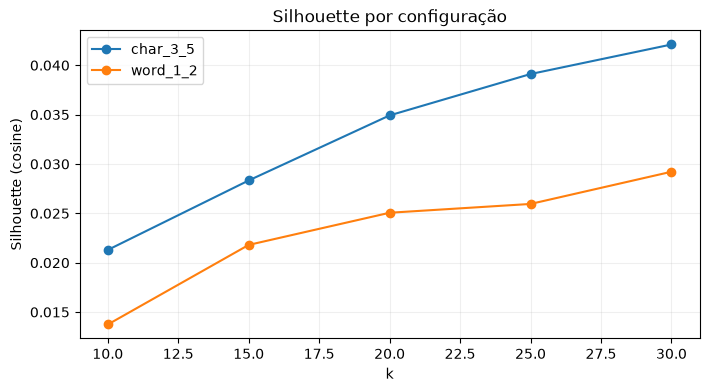

In [24]:

fig, ax = plt.subplots(figsize=(8, 4))

for config_name, group in results.groupby("config"):
    ax.plot(group["k"], group["silhouette_cosine"], marker="o", label=config_name)

ax.set_title("Silhouette por configuração")
ax.set_xlabel("k")
ax.set_ylabel("Silhouette (cosine)")
ax.legend()
ax.grid(alpha=0.2)

plt.show()


## 6. Treinar uma configuração para inspeção

In [25]:

# Para o protótipo enxuto, selecionamos automaticamente a configuração
# com maior silhouette. No experimento final, faça também avaliação qualitativa.

best_row = results.sort_values(
    ["silhouette_cosine", "davies_bouldin_amostra"],
    ascending=[False, True],
).iloc[0]

BEST_CONFIG = best_row["config"]
BEST_K = int(best_row["k"])

print("Configuração escolhida para inspeção:", BEST_CONFIG)
print("k escolhido:", BEST_K)

vectorizer = TfidfVectorizer(**CONFIGS[BEST_CONFIG])
X = vectorizer.fit_transform(texts)

kmeans = KMeans(
    n_clusters=BEST_K,
    random_state=RANDOM_STATE,
    n_init=10,
)
labels = kmeans.fit_predict(X)

desc["cluster"] = labels

display(
    desc.groupby("cluster")
        .agg(
            descricoes_unicas=("descricao_normalizada", "size"),
            ocorrencias=("frequencia", "sum"),
        )
        .sort_values("ocorrencias", ascending=False)
)


Configuração escolhida para inspeção: char_3_5
k escolhido: 30


,descricoes_unicas,ocorrencias
cluster,,
3,6657,9230
4,997,1441
8,449,642
19,539,596
7,465,578
12,424,563
2,393,525
13,321,494
10,407,461


## 7. Exemplos representativos dos clusters

In [26]:

# Distância de cada descrição ao centroide do cluster ao qual ela foi atribuída.
all_distances = kmeans.transform(X)
assigned_distance = all_distances[np.arange(X.shape[0]), labels]
desc["distancia_centroide"] = assigned_distance

feature_names = np.array(vectorizer.get_feature_names_out())

def top_features_for_cluster(cluster_id, n=12):
    centroid = kmeans.cluster_centers_[cluster_id]
    idx = np.argsort(centroid)[::-1][:n]
    return feature_names[idx].tolist()

def cluster_summary(cluster_id, n_center=5, n_edge=5, n_random=5):
    subset = desc[desc["cluster"] == cluster_id].copy()

    central = subset.nsmallest(n_center, "distancia_centroide")
    edge = subset.nlargest(n_edge, "distancia_centroide")
    random = subset.sample(
        min(n_random, len(subset)),
        random_state=RANDOM_STATE + cluster_id,
    )

    return {
        "cluster": cluster_id,
        "n_descricoes_unicas": len(subset),
        "n_ocorrencias": int(subset["frequencia"].sum()),
        "termos_relevantes": top_features_for_cluster(cluster_id),
        "centrais": central["exemplo_original"].tolist(),
        "borda": edge["exemplo_original"].tolist(),
        "aleatorios": random["exemplo_original"].tolist(),
    }


summaries = [cluster_summary(i) for i in range(BEST_K)]
cluster_report = pd.DataFrame(summaries)

display(cluster_report.head())


,cluster,n_descricoes_unicas,n_ocorrencias,termos_relevantes,centrais,borda,aleatorios
0,0,138,274,"[ 202, 202, 2023, 2023, 023, 20, ano , ano...",[PNLD 2023 Obj2 - Livro de prat - Arte- 1o ano...,"[O MURO NO MEIO DO LIVRO (PNLD 2022) DIG MP, D...","[2027V - APIS MAIS MATEMATICA 5 ANO- 2023P, 20..."
1,1,332,377,"[eira, ira , eira , ira, eir, ra , deir, dei, ...","[CADEIRA, ABRACADEIRA, CADEIRA FIXA, BANCO DE ...","[SORV POTE 2L BRIGADEIRO UN, MINIBOOK_SEMFRONT...","[FRIGIDEIRA, CADEIRA ESC. ESTOF. 7/8 INJ. T. A..."
2,2,393,525,"[ment, men, ent, ento, mento, ento , nto, nto ...","[CIMENTO, CIMENTO 50 KG, CIMENTO CSN CPII F32,...","[Ventoinha, JOGO DE DOIS ELEMENT, ASSENTO SANI...","[CENTO DE CROISSANT, EMBUCHAMENTO HORIZONTAL C..."
3,3,6657,9230,"[ de, de , co, de , ado, or , ca, do , te ,...",[SORTIDO CONTENTO APARELHO COMUTADOR DE DADOS ...,"[1N4739, 74HC74, BC558, CD4511, PBS PH 72]","[PNEU 215/75 R17.5 MC01, GAS P 45, BAGAGEIRO B..."
4,4,997,1441,"[cao, cao , ao , ara , ara, para , par, par, ...",[Item compra: 00061 - Reagente para diagnostic...,"[SOLUCAO LIMPEZA MULTIUSO, FERRO P CONSTRUCAO ...","[Folha de louro desidratada, em folhas. Aprese..."


In [ ]:

# Escolha um cluster para inspecionar em detalhe.
CLUSTER_ID = 0

summary = summaries[CLUSTER_ID]

print("CLUSTER:", summary["cluster"])
print("Descrições únicas:", summary["n_descricoes_unicas"])
print("Ocorrências:", summary["n_ocorrencias"])
print("\nTermos/n-grams relevantes:")
print(summary["termos_relevantes"])

print("\nExemplos centrais:")
for x in summary["centrais"]:
    print("-", x)

print("\nExemplos de borda:")
for x in summary["borda"]:
    print("-", x)

print("\nExemplos aleatórios:")
for x in summary["aleatorios"]:
    print("-", x)


## 8. Gerar prompts para nomeação com LLM

In [ ]:

def build_llm_prompt(summary):
    return f"""
Você está apoiando a construção de uma taxonomia plana de categorias de produtos
a partir de descrições curtas de itens de notas fiscais.

Analise o cluster abaixo.

Cluster: {summary['cluster']}
Quantidade de descrições únicas: {summary['n_descricoes_unicas']}
Quantidade total de ocorrências: {summary['n_ocorrencias']}

Termos ou n-grams relevantes:
{summary['termos_relevantes']}

Exemplos centrais:
{summary['centrais']}

Exemplos de borda:
{summary['borda']}

Exemplos aleatórios:
{summary['aleatorios']}

Retorne:
1. Um rótulo curto e interpretável para o cluster.
2. Uma justificativa breve.
3. Indique se o cluster parece:
   - coerente;
   - parcialmente coerente;
   - heterogêneo.
4. Aponte se o rótulo está excessivamente influenciado por marca,
   tamanho, unidade ou outra característica que não represente uma categoria de produto.
""".strip()


cluster_report["prompt_llm"] = [
    build_llm_prompt(summary)
    for summary in summaries
]

print(cluster_report.loc[0, "prompt_llm"])



Nesta versão enxuta, os prompts podem ser copiados para uma LLM manualmente.  
Depois da revisão humana, associe cada cluster a uma categoria na célula seguinte.


## 9. Taxonomia plana — validação humana

In [ ]:

# PREENCHA APÓS INSPECIONAR OS CLUSTERS.
# Exemplo:
# TAXONOMY = {
#     0: "Refrigerantes",
#     1: "Produtos de limpeza",
#     2: "Laticínios",
# }

TAXONOMY = {}

desc["categoria"] = desc["cluster"].map(TAXONOMY).fillna("REVISAR")

display(
    desc.groupby(["cluster", "categoria"])
        .agg(
            descricoes_unicas=("descricao_normalizada", "size"),
            ocorrencias=("frequencia", "sum"),
        )
        .reset_index()
        .sort_values("ocorrencias", ascending=False)
)


## 10. Categorizar novas descrições

In [ ]:

def categorize_new_descriptions(new_descriptions):
    normalized = [normalize_text(x) for x in new_descriptions]
    X_new = vectorizer.transform(normalized)
    cluster_ids = kmeans.predict(X_new)

    result = pd.DataFrame({
        "descricao_original": new_descriptions,
        "descricao_normalizada": normalized,
        "cluster": cluster_ids,
    })

    result["categoria"] = result["cluster"].map(TAXONOMY).fillna("REVISAR")
    return result


teste = [
    "COCA COLA PET 2L",
    "SABAO EM PO 1KG",
    "LEITE INTEGRAL 1L",
]

display(categorize_new_descriptions(teste))


## 11. Exportar resultados do experimento

In [ ]:

OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

results.to_csv(
    OUTPUT_DIR / "metricas_teste_janeiro_2025.csv",
    index=False,
    encoding="utf-8-sig",
)

cluster_report.to_csv(
    OUTPUT_DIR / "resumo_clusters_janeiro_2025.csv",
    index=False,
    encoding="utf-8-sig",
)

desc.to_csv(
    OUTPUT_DIR / "descricoes_clusterizadas_janeiro_2025.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Arquivos salvos em:", OUTPUT_DIR.resolve())



## Próximos passos depois que este notebook funcionar

Para sair deste teste enxuto e avançar para o experimento do TCC:

- aumentar a amostra;
- testar mais valores de `k`;
- comparar sistematicamente n-grams de palavras e caracteres;
- testar variações de pré-processamento;
- registrar cada experimento;
- revisar qualitativamente todos os clusters;
- gerar e validar os rótulos com LLM;
- consolidar a taxonomia final;
- separar descrições não usadas na construção da taxonomia para testar a categorização inicial.
